# Replication of Table 1 & Table 2
## Walk-Forward Out-of-Sample Portfolio Performance

This notebook replicates **Table 1** (walk-forward performance metrics) and **Table 2** (aggregated OOS Sharpe ratios) from the QHRP paper.

**Strategies compared:**
- Quantum HRP
- Classical HRP
- Kernel-based HRP
- Markowitz (inverse-variance)
- Equal Weights (1/N)

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew, kurtosis
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import os
import sys
import time as _time
import pickle
from joblib import Parallel, delayed

# Add RiskLabAI to path
sys.path.insert(0, os.path.abspath("../../repos/RiskLabAI.py"))
from RiskLabAI.optimization import hrp, recursive_bisection

# Add local quantum_hrp module
sys.path.insert(0, os.path.abspath("../qhrp_figure3_4"))
from src.quantum_hrp import (
    compute_financial_features,
    average_density_matrix,
    compute_distance_matrix,
    quantum_ordering,
    classical_hrp_ordering,
    frobenius_distance,
    sharpe_ratio,
    probabilistic_sharpe_ratio,
    min_track_record_length,
    markowitz_weights,
    equal_weights,
    quasi_diagonal,
    distance_corr,
    gaussian_mmd_distance,
    compute_kernel_distance_matrix,
    kernel_based_hrp_ordering,
)

print("All imports OK")

All imports OK


In [13]:
# ── Configuration ─────────────────────────────────────────────────────────
DATA_DIR = os.path.abspath("../../data")
OUT_DIR  = os.path.abspath("../../latex/img")
CACHE_DIR = os.path.abspath("./cache")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  QUICK TEST MODE: set to True to run only a few windows first,        │
# │  verify correctness, then set to False for the full run.               │
# └─────────────────────────────────────────────────────────────────────────┘
QUICK_TEST      = False    # Only 18 windows total — no need for quick test
QUICK_N_WINDOWS = 10       # number of windows in quick-test mode

# Walk-forward parameters (matching paper)
TRAINING_WINDOW = 756   # ~3 years of trading days
TEST_WINDOW     = 21    # ~1 month
ALPHA           = 2.0   # quantum feature map parameter
P_FEATURES      = 6     # number of features (6 financial features per timestep)
RF              = 0.01  # annual risk-free rate
TARGET_SR       = 0     # benchmark Sharpe for PSR
CONFIDENCE      = 0.95  # confidence for MinTRL

# Parallelisation
N_JOBS = -1  # use all CPU cores (-1), or set to a fixed number

print(f"Training window: {TRAINING_WINDOW} days")
print(f"Test window:     {TEST_WINDOW} days")
print(f"Features:        P={P_FEATURES}")
if QUICK_TEST:
    print(f"Quick test:      ON ({QUICK_N_WINDOWS} windows)")
else:
    print(f"Quick test:      OFF (full run)")
print(f"Parallelisation: {N_JOBS} cores")

Training window: 756 days
Test window:     21 days
Features:        P=6
Quick test:      OFF (full run)
Parallelisation: -1 cores


In [14]:
# ── Load pre-computed data (paper's exact pipeline from prepare_data.py) ──
# features.npy shape: (N, T, P=6) — computed via compute_financial_features
# returns.csv shape:  (T, N)      — global dropna(how='any') on all tickers
# This matches the paper's fetch_stock_data pipeline exactly.

features_all = np.load(os.path.join(DATA_DIR, "features.npy"))    # (N, T, 6)
returns_df   = pd.read_csv(os.path.join(DATA_DIR, "returns.csv"),
                           index_col=0, parse_dates=True)
tickers_df   = pd.read_csv(os.path.join(DATA_DIR, "tickers.csv"))

# Handle NaN in features (t=0 rolling stats produce NaN)
features_all = np.nan_to_num(features_all, nan=0.0)

R = returns_df.values                   # (T, N)
T_total, N = R.shape
ticker_names = tickers_df["ticker"].tolist()

print(f"Features loaded: {features_all.shape}  →  (N={N}, T={T_total}, P={features_all.shape[2]})")
print(f"Returns loaded:  {returns_df.shape}     →  (T={T_total}, N={N})")
print(f"Date range: {returns_df.index.min().date()} → {returns_df.index.max().date()}")
print(f"Tickers: {ticker_names[:10]} ... ({N} total)")

Features loaded: (169, 1147, 6)  →  (N=169, T=1147, P=6)
Returns loaded:  (1147, 169)     →  (T=1147, N=169)
Date range: 2021-11-11 → 2024-12-31
Tickers: ['SPY', 'QQQ', 'DIA', 'IWM', 'IVV', 'VTI', 'VOO', 'EFA', 'EEM', 'VEA'] ... (169 total)


In [15]:
# ── Helpers ───────────────────────────────────────────────────────────────
import pickle
from joblib import Parallel, delayed

def hrp_recursive_bisection(cov, sorted_items):
    """Compute HRP weights via recursive bisection."""
    cov_df = pd.DataFrame(cov)
    return recursive_bisection(cov_df, sorted_items)

def compute_density_for_asset(feat, alpha):
    """Compute average density matrix for one asset (parallelisable)."""
    return average_density_matrix(feat, alpha)

def compute_all_densities_parallel(training_features, alpha, n_jobs):
    """Compute density matrices for all N assets in parallel."""
    rho_list = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(compute_density_for_asset)(feat, alpha)
        for feat in training_features
    )
    return rho_list

def save_checkpoint(results, w, path):
    """Save partial results to disk."""
    with open(path, "wb") as f:
        pickle.dump({"results": results, "last_window": w}, f)

def load_checkpoint(path):
    """Load partial results from disk."""
    if os.path.exists(path):
        with open(path, "rb") as f:
            data = pickle.load(f)
        return data["results"], data["last_window"]
    return None, -1

print("Helpers defined.")

Helpers defined.


In [16]:
# ── Walk-Forward Out-of-Sample Analysis ──────────────────────────────────
CHECKPOINT_PATH = os.path.join(CACHE_DIR, "walkforward_checkpoint.pkl")

num_windows_total = (T_total - TRAINING_WINDOW) // TEST_WINDOW
num_windows = QUICK_N_WINDOWS if QUICK_TEST else num_windows_total
print(f"Total possible windows: {num_windows_total}")
print(f"Running: {num_windows} windows {'(QUICK TEST)' if QUICK_TEST else '(FULL RUN)'}")
print(f"Assets: N={N} (fixed across all windows)")

# Try to resume from checkpoint (only for full runs)
METHODS = ["Quantum HRP", "Classical HRP", "Kernel HRP", "Markowitz", "Equal Weights"]
start_window = 0
if not QUICK_TEST:
    cached_results, last_w = load_checkpoint(CHECKPOINT_PATH)
    if cached_results is not None and last_w >= 0:
        results = cached_results
        start_window = last_w + 1
        print(f"▶ Resuming from window {start_window} (checkpoint found)")
    else:
        results = {m: {"sr": [], "psr": [], "trl": [], "oos_returns": []} for m in METHODS}
else:
    results = {m: {"sr": [], "psr": [], "trl": [], "oos_returns": []} for m in METHODS}

t0_total = _time.time()

for w in range(start_window, num_windows):
    t0_win = _time.time()

    train_start = w * TEST_WINDOW
    train_end   = train_start + TRAINING_WINDOW
    test_start  = train_end
    test_end    = test_start + TEST_WINDOW
    if test_end > T_total:
        break

    # Extract training/testing arrays (all N assets, no NaN in this data)
    training_returns = R[train_start:train_end, :]    # (756, N)
    testing_returns  = R[test_start:test_end, :]      # (21, N)

    # Extract pre-computed features for training window
    # features_all shape: (N, T, 6) → for each asset i, slice [train_start:train_end]
    training_features = [features_all[i, train_start:train_end, :] for i in range(N)]

    # ── Quantum HRP ordering (parallelised density computation) ──
    avg_rho_list = compute_all_densities_parallel(training_features, ALPHA, N_JOBS)
    D_quantum = compute_distance_matrix(avg_rho_list)
    q_order = quantum_ordering(D_quantum)

    # ── Classical HRP ordering ──
    classical_order = classical_hrp_ordering(training_returns)

    # ── Kernel-based HRP ordering ──
    kernel_order = kernel_based_hrp_ordering(training_features, sigma=1.0)

    # ── Covariance & weights ──
    cov = np.cov(training_returns, rowvar=False)

    w_qhrp      = hrp_recursive_bisection(cov, list(q_order)).sort_index().values
    w_classical = pd.Series(hrp_recursive_bisection(cov, list(classical_order))).sort_index().values
    w_kernel    = hrp_recursive_bisection(cov, list(kernel_order)).sort_index().values
    w_marko     = markowitz_weights(cov)
    w_equal     = equal_weights(N)

    # Normalise
    for ww in [w_qhrp, w_classical, w_kernel, w_marko, w_equal]:
        ww /= ww.sum()

    weights_map = {
        "Quantum HRP": w_qhrp, "Classical HRP": w_classical,
        "Kernel HRP": w_kernel, "Markowitz": w_marko, "Equal Weights": w_equal,
    }

    for method, w_vec in weights_map.items():
        port_ret = testing_returns.dot(w_vec)
        sr_val, psr_val, _, _ = probabilistic_sharpe_ratio(
            port_ret, TARGET_SR, rf=RF, annualization_factor=252
        )
        results[method]["sr"].append(sr_val)
        results[method]["psr"].append(psr_val)
        results[method]["oos_returns"].extend(port_ret.tolist())
        if "HRP" in method:
            trl_val = min_track_record_length(port_ret, TARGET_SR, CONFIDENCE)
            results[method]["trl"].append(trl_val)

    # ── Progress ──
    dt_win = _time.time() - t0_win
    elapsed = _time.time() - t0_total
    remaining_wins = num_windows - (w + 1)
    avg_per_win = elapsed / (w - start_window + 1)
    eta = remaining_wins * avg_per_win

    print(
        f"  [{w+1:>4d}/{num_windows}]  "
        f"N={N}  |  window: {dt_win:.1f}s  |  elapsed: {elapsed:.0f}s  |  "
        f"ETA: {eta/60:.1f}min  |  "
        f"SR(Q)={results['Quantum HRP']['sr'][-1]:.2f}  "
        f"SR(C)={results['Classical HRP']['sr'][-1]:.2f}"
    )

    # ── Checkpoint every 5 windows (full run only) ──
    if not QUICK_TEST and (w + 1) % 5 == 0:
        save_checkpoint(results, w, CHECKPOINT_PATH)

# Final save
if not QUICK_TEST:
    save_checkpoint(results, w, CHECKPOINT_PATH)
    print(f"\n✓ Checkpoint saved to {CHECKPOINT_PATH}")

elapsed_total = _time.time() - t0_total
n_wins = w + 1 - start_window
print(f"\nWalk-forward complete: {n_wins} windows in {elapsed_total:.1f}s ({elapsed_total/60:.1f}min)")

Total possible windows: 18
Running: 18 windows (FULL RUN)
Assets: N=169 (fixed across all windows)
  [   1/18]  N=169  |  window: 1622.4s  |  elapsed: 1622s  |  ETA: 459.7min  |  SR(Q)=6.41  SR(C)=6.28
  [   2/18]  N=169  |  window: 1620.9s  |  elapsed: 3243s  |  ETA: 432.4min  |  SR(Q)=-4.99  SR(C)=-4.58
  [   3/18]  N=169  |  window: 1624.0s  |  elapsed: 4867s  |  ETA: 405.6min  |  SR(Q)=2.52  SR(C)=1.89
  [   4/18]  N=169  |  window: 1620.7s  |  elapsed: 6488s  |  ETA: 378.5min  |  SR(Q)=0.21  SR(C)=0.03
  [   5/18]  N=169  |  window: 1619.8s  |  elapsed: 8108s  |  ETA: 351.3min  |  SR(Q)=5.36  SR(C)=5.90
  [   6/18]  N=169  |  window: 1622.2s  |  elapsed: 9730s  |  ETA: 324.3min  |  SR(Q)=-2.95  SR(C)=-3.45
  [   7/18]  N=169  |  window: 1629.7s  |  elapsed: 11360s  |  ETA: 297.5min  |  SR(Q)=-1.58  SR(C)=-1.65
  [   8/18]  N=169  |  window: 1618.6s  |  elapsed: 12978s  |  ETA: 270.4min  |  SR(Q)=6.99  SR(C)=7.84
  [   9/18]  N=169  |  window: 1629.9s  |  elapsed: 14608s  |  ETA: 2

In [17]:
# ══════════════════════════════════════════════════════════════════════════
# TABLE 1 — Walk-Forward Performance (per-window statistics)
# ══════════════════════════════════════════════════════════════════════════
table1_rows = []
for m in METHODS:
    sr_arr  = np.array(results[m]["sr"])
    psr_arr = np.array(results[m]["psr"])
    table1_rows.append({
        "Method":       m,
        "Mean Sharpe":  f"{np.mean(sr_arr):.4f}",
        "Std Sharpe":   f"{np.std(sr_arr):.4f}",
        "Mean PSR":     f"{np.mean(psr_arr):.4f}",
    })

table1 = pd.DataFrame(table1_rows).set_index("Method")
n_wins = len(results[METHODS[0]]["sr"])
print(f"Table 1 — Walk-Forward Performance (Out-of-Sample) [{n_wins} windows]")
print("=" * 60)
print(table1.to_string())
print()
display(table1.style.set_caption(f"Table 1 — Walk-Forward Performance ({n_wins} windows)"))

Table 1 — Walk-Forward Performance (Out-of-Sample) [18 windows]
              Mean Sharpe Std Sharpe Mean PSR
Method                                       
Quantum HRP        1.5016     3.7837   0.6191
Classical HRP      1.2754     3.9986   0.5976
Kernel HRP         1.2928     3.7140   0.6054
Markowitz          1.3449     3.7788   0.6089
Equal Weights      1.5076     3.9906   0.6113



,Mean Sharpe,Std Sharpe,Mean PSR
Method,,,
Quantum HRP,1.5016,3.7837,0.6191
Classical HRP,1.2754,3.9986,0.5976
Kernel HRP,1.2928,3.7140,0.6054
Markowitz,1.3449,3.7788,0.6089
Equal Weights,1.5076,3.9906,0.6113


In [18]:
# ══════════════════════════════════════════════════════════════════════════
# TABLE 2 — Aggregated Out-of-Sample Sharpe Ratio
# ══════════════════════════════════════════════════════════════════════════
table2_rows = []
for m in METHODS:
    oos_ret = np.array(results[m]["oos_returns"])
    agg_sr = sharpe_ratio(oos_ret, rf=RF, annualization_factor=252)
    table2_rows.append({
        "Method":                m,
        "Aggregated OOS Sharpe": f"{agg_sr:.4f}",
    })

table2 = pd.DataFrame(table2_rows).set_index("Method")
print(f"Table 2 — Aggregated Out-of-Sample Sharpe Ratio [{n_wins} windows]")
print("=" * 60)
print(table2.to_string())
print()
display(table2.style.set_caption(f"Table 2 — Aggregated OOS Sharpe Ratio ({n_wins} windows)"))

Table 2 — Aggregated Out-of-Sample Sharpe Ratio [18 windows]
              Aggregated OOS Sharpe
Method                             
Quantum HRP                  1.4441
Classical HRP                1.2378
Kernel HRP                   1.1803
Markowitz                    1.2518
Equal Weights                1.3193



,Aggregated OOS Sharpe
Method,
Quantum HRP,1.4441
Classical HRP,1.2378
Kernel HRP,1.1803
Markowitz,1.2518
Equal Weights,1.3193


In [19]:
# ══════════════════════════════════════════════════════════════════════════
# Additional: MinTRL for HRP methods
# ══════════════════════════════════════════════════════════════════════════
print("Average Minimum Track Record Length (MinTRL):")
for m in ["Quantum HRP", "Classical HRP", "Kernel HRP"]:
    trl_arr = np.array(results[m]["trl"])
    # Filter out inf values for mean computation
    trl_finite = trl_arr[np.isfinite(trl_arr)]
    if len(trl_finite) > 0:
        print(f"  {m}: {np.mean(trl_finite):.4f} observations ({len(trl_finite)}/{len(trl_arr)} finite)")
    else:
        print(f"  {m}: all inf")

Average Minimum Track Record Length (MinTRL):
  Quantum HRP: 20.7366 observations (12/18 finite)
  Classical HRP: 410.8921 observations (11/18 finite)
  Kernel HRP: 3.5794 observations (11/18 finite)


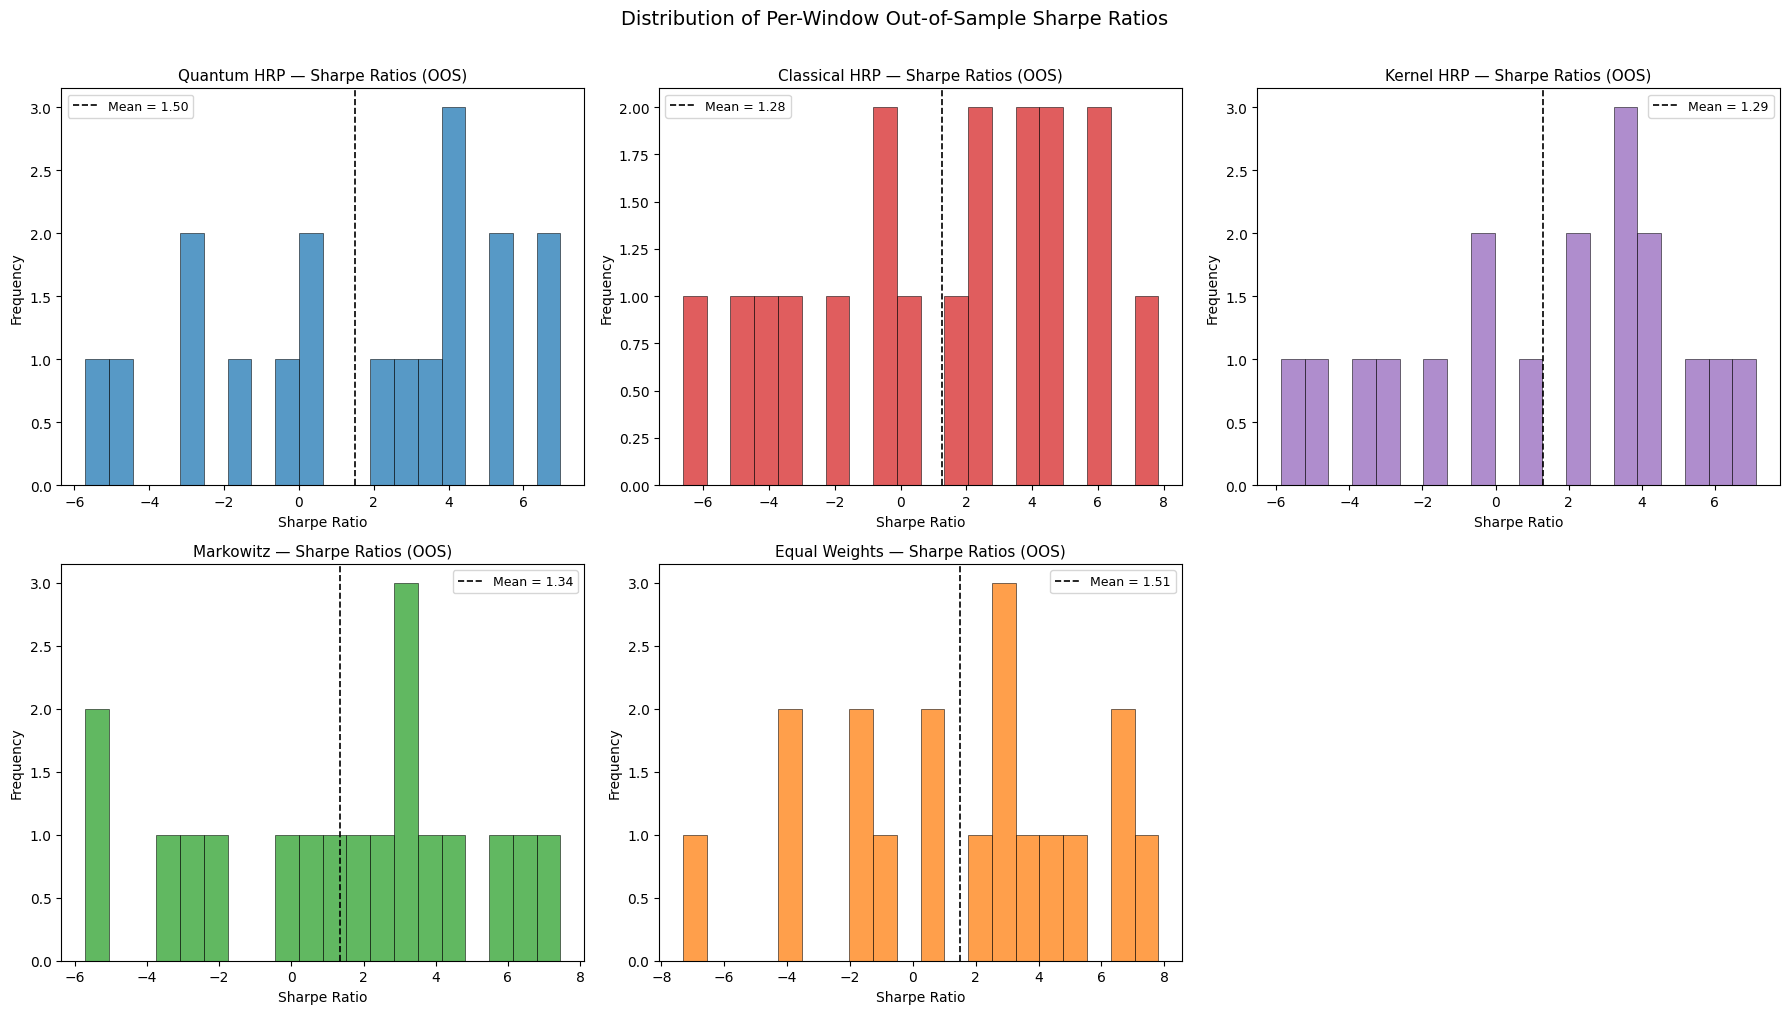

In [20]:
# ══════════════════════════════════════════════════════════════════════════
# Histograms of per-window Sharpe ratios (Figure 5 from the paper)
# ══════════════════════════════════════════════════════════════════════════
colors = {
    "Quantum HRP":  "tab:blue",
    "Classical HRP": "tab:red",
    "Kernel HRP":   "tab:purple",
    "Markowitz":    "tab:green",
    "Equal Weights": "tab:orange",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for idx, m in enumerate(METHODS):
    ax = axes_flat[idx]
    sr_arr = np.array(results[m]["sr"])
    ax.hist(sr_arr, bins=20, color=colors[m], alpha=0.75, edgecolor="black", linewidth=0.5)
    ax.axvline(np.mean(sr_arr), color="black", linestyle="--", linewidth=1.2,
               label=f"Mean = {np.mean(sr_arr):.2f}")
    ax.set_title(f"{m} — Sharpe Ratios (OOS)", fontsize=11)
    ax.set_xlabel("Sharpe Ratio")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

# Turn off the last (unused) subplot
axes_flat[-1].set_visible(False)

plt.suptitle("Distribution of Per-Window Out-of-Sample Sharpe Ratios", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "table1-sharpe-histograms.png"), dpi=300, bbox_inches="tight")
plt.show()

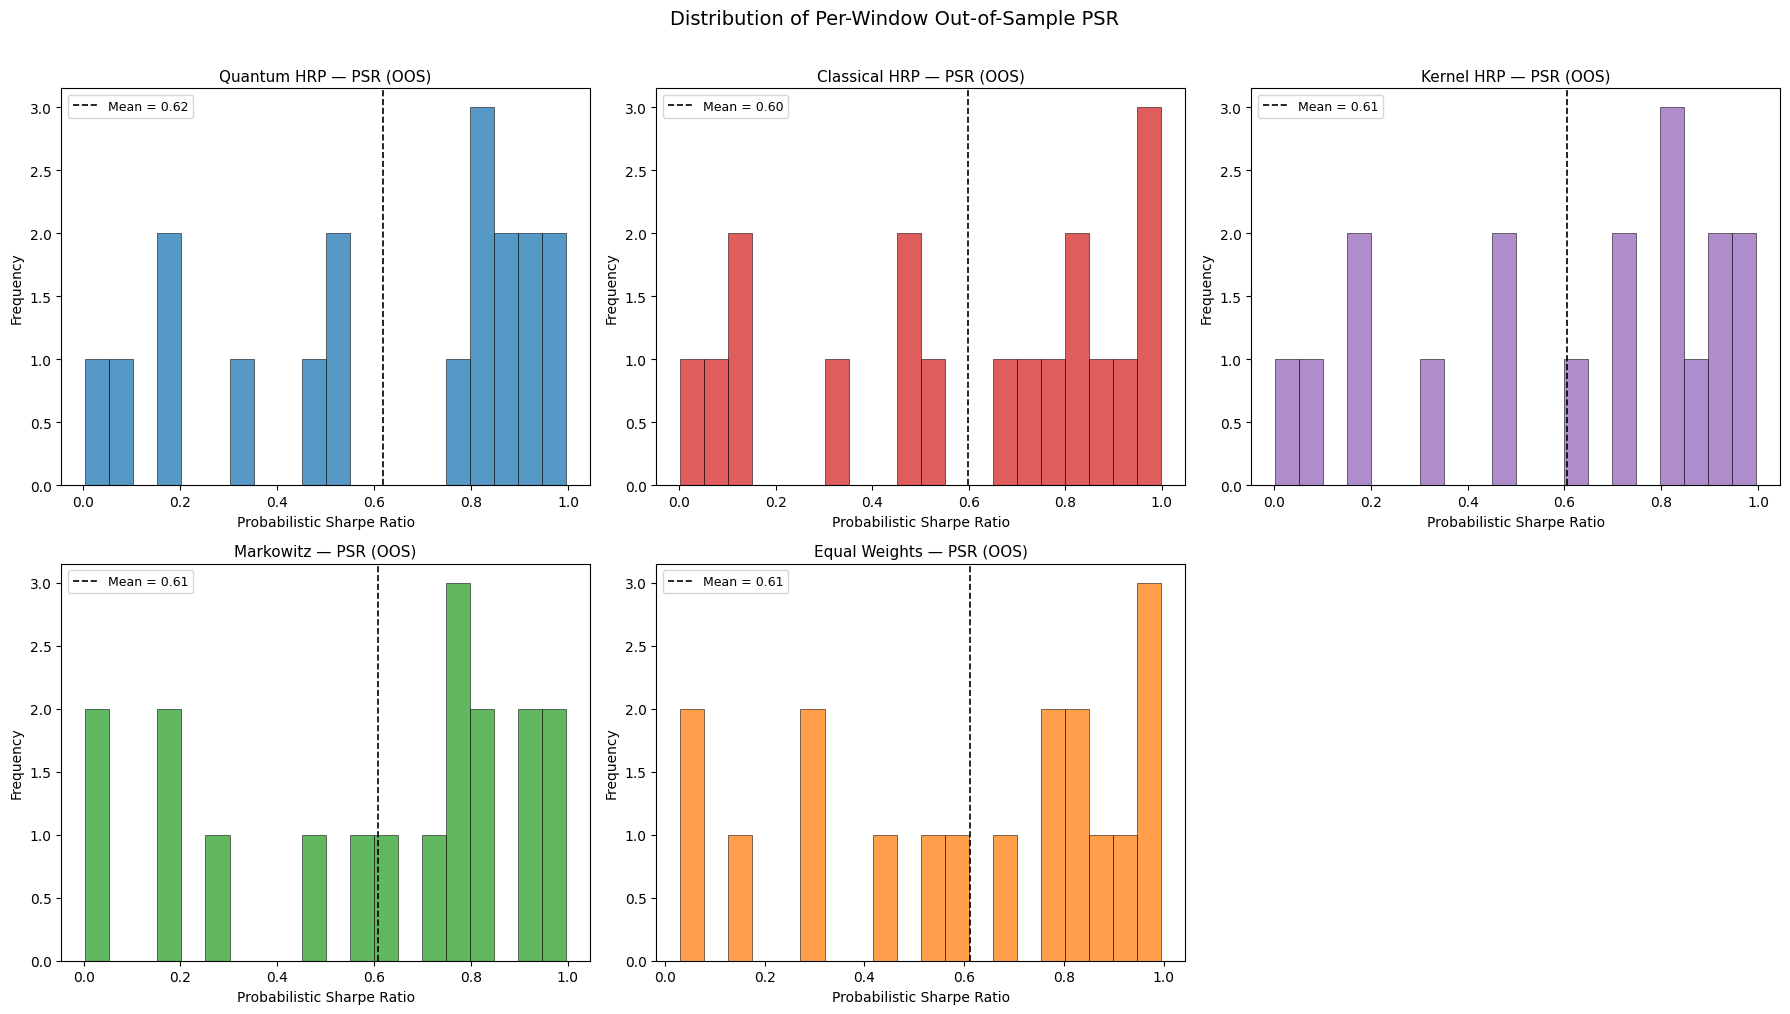

In [21]:
# ══════════════════════════════════════════════════════════════════════════
# Histograms of per-window PSR
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for idx, m in enumerate(METHODS):
    ax = axes_flat[idx]
    psr_arr = np.array(results[m]["psr"])
    ax.hist(psr_arr, bins=20, color=colors[m], alpha=0.75, edgecolor="black", linewidth=0.5)
    ax.axvline(np.mean(psr_arr), color="black", linestyle="--", linewidth=1.2,
               label=f"Mean = {np.mean(psr_arr):.2f}")
    ax.set_title(f"{m} — PSR (OOS)", fontsize=11)
    ax.set_xlabel("Probabilistic Sharpe Ratio")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

axes_flat[-1].set_visible(False)

plt.suptitle("Distribution of Per-Window Out-of-Sample PSR", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "table1-psr-histograms.png"), dpi=300, bbox_inches="tight")
plt.show()

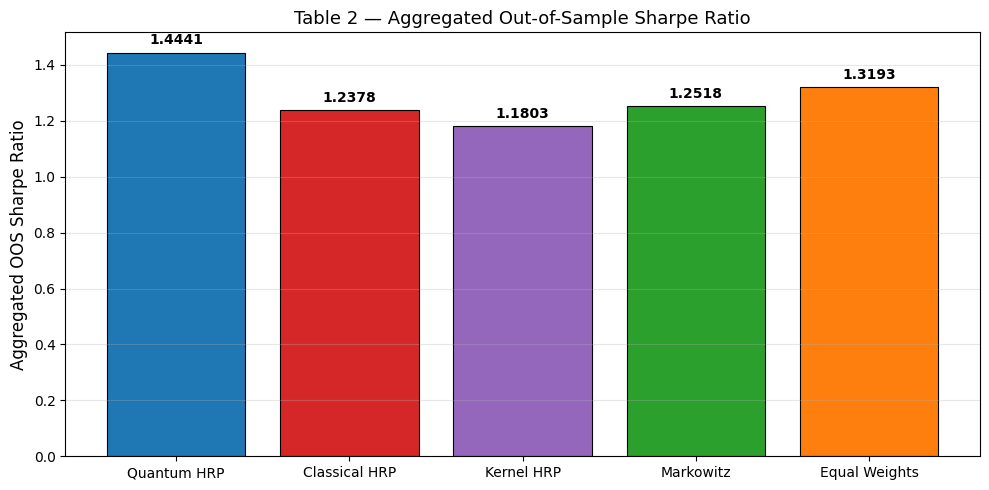

In [22]:
# ══════════════════════════════════════════════════════════════════════════
# Bar chart comparison — Table 2 (Aggregated Sharpe)
# ══════════════════════════════════════════════════════════════════════════
agg_sharpes = {}
for m in METHODS:
    oos_ret = np.array(results[m]["oos_returns"])
    agg_sharpes[m] = sharpe_ratio(oos_ret, rf=RF, annualization_factor=252)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    agg_sharpes.keys(), agg_sharpes.values(),
    color=[colors[m] for m in METHODS],
    edgecolor="black", linewidth=0.8
)
for bar, val in zip(bars, agg_sharpes.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Aggregated OOS Sharpe Ratio", fontsize=12)
ax.set_title("Table 2 — Aggregated Out-of-Sample Sharpe Ratio", fontsize=13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "table2-aggregated-sharpe.png"), dpi=300, bbox_inches="tight")
plt.show()